In [164]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [165]:
file_path = Path("Datasets/LMS_2013-01-01_2026-03-24_HALF_HOUR_au.pq")
df = pd.read_parquet(file_path)
df.head()

,date,6102000812 consumption,6102002302 consumption,6102005454 consumption,6102005592 consumption,6102009742 consumption,6102009743 consumption,6102009744 consumption,6102023971 consumption,6102038376 consumption,...,VAAA003176 consumption,VAAA003194 consumption,VAAA003197 consumption,VAAA003225 consumption,VAAA003429 consumption,VAAA004066 consumption,VCCCAE0035 consumption,VCCCBC0096 consumption,VCCCSC0045 consumption,VCCCSD0058 consumption
0,2013-01-01 00:00:00,20.768,11.659,24.76,17.92,5.232,18.735,13.199,204.30,70.84,...,16.74,19.76,28.20,6.932,0.0,0.0,95.968,23.490,9.320,21.087
1,2013-01-01 00:30:00,20.512,11.260,24.64,18.52,5.376,18.700,13.020,207.66,70.56,...,17.76,19.82,28.72,6.842,0.0,0.0,96.512,23.865,9.072,19.296
2,2013-01-01 01:00:00,20.544,11.459,24.92,18.20,4.720,18.644,13.620,205.68,69.52,...,17.46,19.68,28.60,7.423,0.0,0.0,95.423,24.165,9.080,19.904
3,2013-01-01 01:30:00,20.688,11.419,24.56,17.72,3.582,17.130,13.260,202.32,70.12,...,17.10,19.76,28.26,6.878,0.0,0.0,98.783,22.380,9.072,19.552
4,2013-01-01 02:00:00,22.032,11.340,24.64,18.92,3.952,17.155,12.899,206.82,92.72,...,18.00,19.74,27.70,6.708,0.0,0.0,98.016,22.995,9.216,20.032


In [166]:
print(df["6103086897 consumption"].value_counts(), '\n')
print(df["VAAA004066 consumption"].value_counts())
print(df["6102136796 consumption"].value_counts())

6103086897 consumption
0.00     231839
11.82         1
Name: count, dtype: int64 

VAAA004066 consumption
0.000     210384
0.320       7856
0.328       7062
0.312       3129
0.336        926
           ...  
0.544          1
5.880          1
0.888          1
11.136         1
1.144          1
Name: count, Length: 88, dtype: int64
6102136796 consumption
0.000    211904
0.176      4400
0.208      2746
0.160      2519
0.200      2079
          ...  
1.264         1
2.768         1
4.776         1
7.640         1
0.592         1
Name: count, Length: 736, dtype: int64


In [167]:
# Delete the specified NMI column
df = df.drop(columns=['6102507141 consumption', 'VAAA003225 consumption', '6103086897 consumption', 'VAAA004066 consumption'])
# Delete the COVID data (2020–2022)
df = df[(df['date'].dt.year < 2020) | (df['date'].dt.year > 2022)]

In [168]:
# Obtain the NMI column
nmi_cols = df.columns[1:]

In [169]:
# 4. Daily Total Consumption
df['day'] = df['date'].dt.date

daily_df = df.groupby('day')[nmi_cols].sum().reset_index()
daily_df['day'] = pd.to_datetime(daily_df['day'])
daily_df['year'] = daily_df['day'].dt.year

In [170]:
# 5. Daily Total Time Series
plot_fig = False
if plot_fig:
    for nmi in nmi_cols:
        plt.figure(figsize=(10, 4))
        plt.plot(daily_df['day'], daily_df[nmi])
        plt.title(f'Daily Total Consumption - {nmi}')
        plt.xlabel('Date')
        plt.ylabel('Consumption')
        plt.tight_layout()
        plt.show()


In [171]:
# 6. Yearly Mean Daily Consumption
if plot_fig:
    for nmi in nmi_cols:
        yearly_mean = daily_df.groupby('year')[nmi].mean()

        plt.figure(figsize=(6, 4))
        yearly_mean.plot(kind='bar')
        plt.title(f'Yearly Mean Daily Consumption - {nmi}')
        plt.xlabel('Year')
        plt.ylabel('Mean Daily Consumption')
        plt.tight_layout()
        plt.show()


In [172]:
# 7. Yearly Load Shape
df['time_of_day'] = df['date'].dt.time
df['year'] = df['date'].dt.year

if plot_fig:
    for nmi in nmi_cols:
        plt.figure(figsize=(10, 5))

        grouped = df.groupby(['year', 'time_of_day'])[nmi].mean().reset_index()

        for year in sorted(grouped['year'].unique()):
            temp = grouped[grouped['year'] == year]
            plt.plot(range(len(temp)), temp[nmi], label=str(year))

        plt.title(f'Average Daily Load Shape by Year - {nmi}')
        plt.xlabel('Half-hour intervals (0–47)')
        plt.ylabel('Average Consumption')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [173]:
# 8. Shortlist 3 NMIs
results = []

for nmi in nmi_cols:
    
    # 1. daily series
    series = daily_df[nmi].dropna()
    
    # 2. slope
    x = np.arange(len(series))
    slope = np.polyfit(x, series, 1)[0]
    
    # 3. std
    std = series.std()
    
    # 4. yearly mean
    yearly = daily_df.groupby('year')[nmi].mean()
    year_diff = yearly.max() - yearly.min()
    
    results.append({
        'nmi': nmi,
        'slope': slope,
        'std': std,
        'year_diff': year_diff
    })

result_df = pd.DataFrame(results)

In [174]:
# most stable (lowest std)
stable_nmi = result_df.sort_values('std').iloc[0]['nmi']

# most trending (highest slope)
trend_nmi = result_df.sort_values('slope', key=abs, ascending=False).iloc[0]['nmi']

# highest yearly variation (possibly breaking)
break_nmi = result_df.sort_values('year_diff', ascending=False).iloc[0]['nmi']

shortlisted_final = [stable_nmi, trend_nmi, break_nmi]

print(shortlisted_final)

['6102136796 consumption', 'VAAA003100 consumption', '6103015873 consumption']


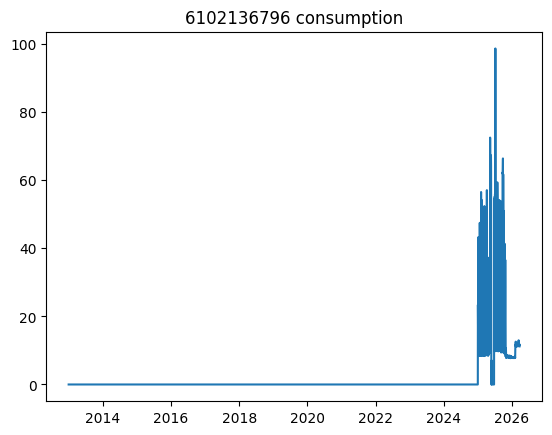

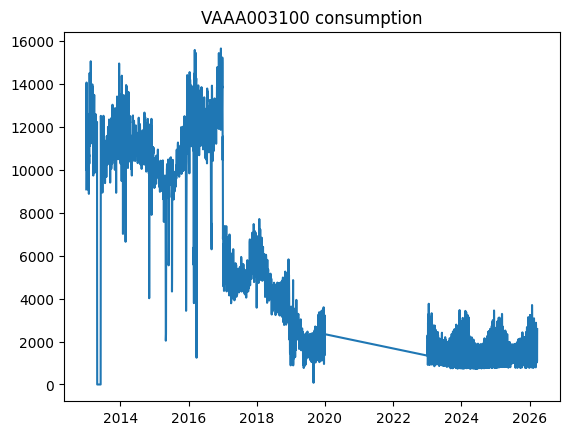

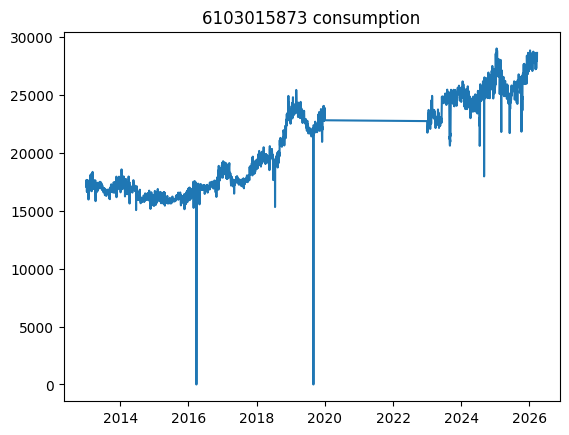

In [175]:
for nmi in shortlisted_final:
    plt.plot(daily_df['day'], daily_df[nmi])
    plt.title(nmi)
    plt.show()

6102136796 consumption

Too many zeros, not meaningful to analyse

⸻

VAAA003100 consumption

Daily Trend:
The series starts with very high consumption levels and gradually declines over time, eventually stabilising at a much lower level.

Yearly Comparison:
There are significant differences across years, with earlier years showing much higher consumption than later years, indicating a strong downward trend.

Load Pattern:
The overall structure of the daily pattern appears to persist, but the magnitude of consumption has decreased substantially.

Final Judgement:
This NMI exhibits a clear downward trend with structural change, possibly reflecting operational changes such as reduced demand or system reconfiguration.

⸻

6103015873 consumption

Daily Trend:
The series shows a gradual upward trend in consumption over time, with relatively stable behaviour aside from occasional sharp drops.

Yearly Comparison:
Yearly averages increase over time, indicating a consistent growth in demand.

Load Pattern:
The daily load shape appears relatively stable across years, suggesting consistent usage behaviour despite increasing consumption levels.

Final Judgement:
This NMI demonstrates a gradually increasing trend with stable structure, making it a strong candidate for forecasting.